In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning and explainability
from sklearn.model_selection import train_test_split
import xgboost as xgb
import shap

# Notebook display settings
%matplotlib inline
pd.set_option('display.max_columns', 50)  # Show all columns

In [48]:
# Load e-commerce fraud data
fraud_data = pd.read_csv('../data/Fraud_Data.csv')
ip_to_country = pd.read_csv('../data/IpAddress_to_Country.csv')

# Load credit card data (if needed)
credit_data = pd.read_csv('../data/creditcard.csv')

# Display first 5 rows to verify
print("E-commerce Data:")
display(fraud_data.head())

print("\nIP to Country Mapping:")
display(ip_to_country.head())

E-commerce Data:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0



IP to Country Mapping:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class,hours_to_purchase,country,time_to_purchase,purchase_hour,purchase_dayofweek,user_transaction_count,device_transaction_count,user_unique_ip_count,ip_unique_device_count,log_purchase_value
0,62421,2015-02-16 00:17:05,2015-03-08 10:00:39,46,ZCLZTAJPCRAQX,Direct,Safari,M,36,52093,0,489.726111,Unknown,1763014.0,10,6,1,1,1,1,3.850148
1,173212,2015-03-08 04:03:22,2015-03-20 17:23:45,33,YFGYOALADBHLT,Ads,IE,F,30,93447,0,301.339722,Unknown,1084823.0,17,4,1,1,1,1,3.526361
2,242286,2015-05-17 16:45:54,2015-05-26 08:54:34,33,QZNVQTUITFTHH,Direct,FireFox,F,32,105818,0,208.144444,Unknown,749320.0,8,1,1,1,1,1,3.526361
3,370003,2015-03-03 19:58:39,2015-05-28 21:09:13,33,PIBUQMBIELMMG,Ads,IE,M,40,117566,0,2065.176111,Unknown,7434634.0,21,3,1,1,1,1,3.526361
4,119824,2015-03-20 00:31:27,2015-04-05 07:31:46,55,WFIIFCPIOGMHT,Ads,Safari,M,38,131423,0,391.005278,Unknown,1407619.0,7,6,1,1,1,1,4.025352


In [7]:
# Check for missing values
print("Missing values in Fraud Data:")
print(fraud_data.isnull().sum())

# Class imbalance check
print("\nFraud Class Distribution:")
print(fraud_data['class'].value_counts(normalize=True))

# Summary statistics
print("\nPurchase Value Stats:")
print(fraud_data['purchase_value'].describe())

Missing values in Fraud Data:
user_id                     0
signup_time                 0
purchase_time               0
purchase_value              0
device_id                   0
source                      0
browser                     0
sex                         0
age                         0
ip_address                  0
class                       0
user_transaction_count      0
time_since_last_purchase    0
dtype: int64

Fraud Class Distribution:
class
0    0.906354
1    0.093646
Name: proportion, dtype: float64

Purchase Value Stats:
count    151112.000000
mean         36.935372
std          18.322762
min           9.000000
25%          22.000000
50%          35.000000
75%          49.000000
max         154.000000
Name: purchase_value, dtype: float64


In [13]:
print(fraud_data.isnull().sum())  # Double-check
print(credit_data.isnull().sum())
print(ip_to_country.isnull().sum())

user_id              0
signup_time          0
purchase_time        0
purchase_value       0
device_id            0
source               0
browser              0
sex                  0
age                  0
ip_address           0
class                0
hours_to_purchase    0
country              0
dtype: int64
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64


In [15]:
print(f"Duplicates removed: Fraud Data: {fraud_data.duplicated().sum()}, Credit Data: {credit_data.duplicated().sum()} ip to country: {ip_to_country.duplicated().sum()}")

Duplicates removed: Fraud Data: 0, Credit Data: 1081 ip to country: 0


In [16]:
# Remove duplicates and verify
credit_data = credit_data.drop_duplicates()
print(f"Duplicates remaining in Credit Data: {credit_data.duplicated().sum()}")

Duplicates remaining in Credit Data: 0


In [8]:
# Convert to correct types
fraud_data = fraud_data.astype({
    'user_id': 'object',
    'device_id': 'object',
    'signup_time': 'datetime64[ns]',
    'purchase_time': 'datetime64[ns]'
})

In [18]:
credit_data.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [19]:
# Numeric features
print(fraud_data[['purchase_value', 'age']].describe())

# Categorical features
print(fraud_data['source'].value_counts())
print(fraud_data['browser'].value_counts())

       purchase_value            age
count   151112.000000  151112.000000
mean        36.935372      33.140704
std         18.322762       8.617733
min          9.000000      18.000000
25%         22.000000      27.000000
50%         35.000000      33.000000
75%         49.000000      39.000000
max        154.000000      76.000000
source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64
browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64


In [20]:
# Transaction amount stats
print(credit_data['Amount'].describe())

# Class distribution
print(credit_data['Class'].value_counts(normalize=True))

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64


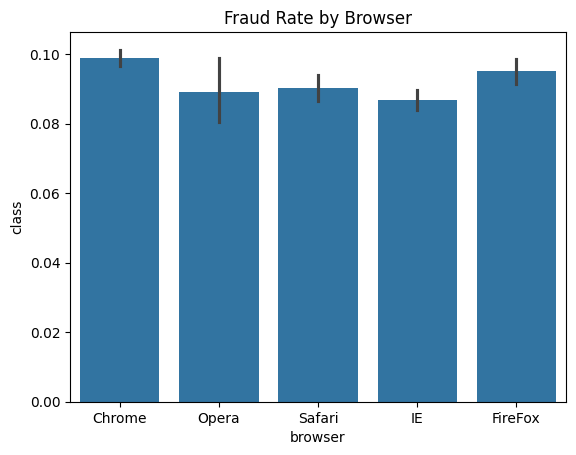

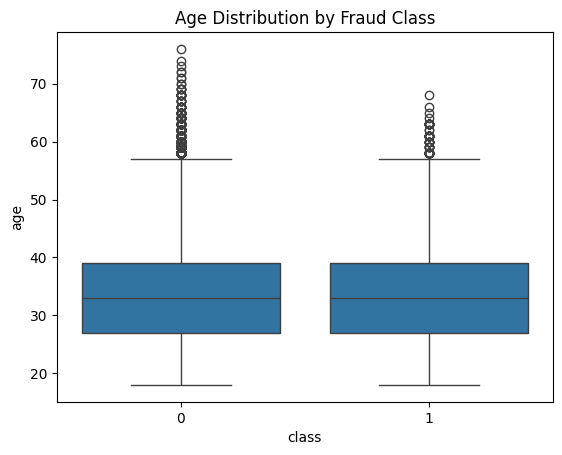

In [21]:
# Fraud rate by browser
sns.barplot(x='browser', y='class', data=fraud_data)
plt.title("Fraud Rate by Browser")
plt.show()

# Age vs Fraud
sns.boxplot(x='class', y='age', data=fraud_data)
plt.title("Age Distribution by Fraud Class")
plt.show()

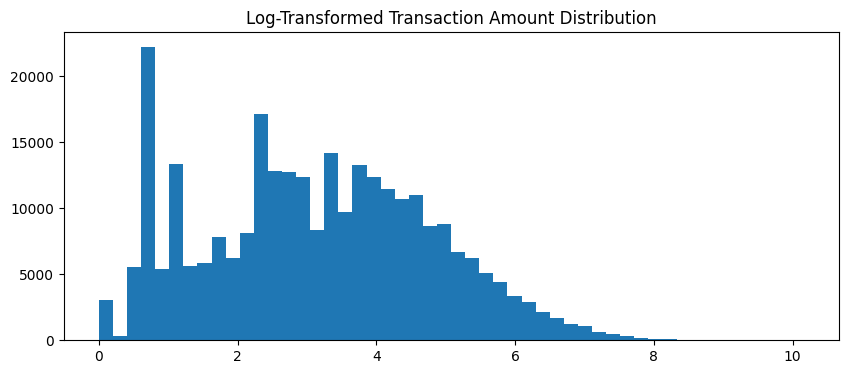

In [23]:
# Distribution of Amount (log-scale for readability)
plt.figure(figsize=(10, 4))
plt.hist(np.log1p(credit_data['Amount']), bins=50)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.show()

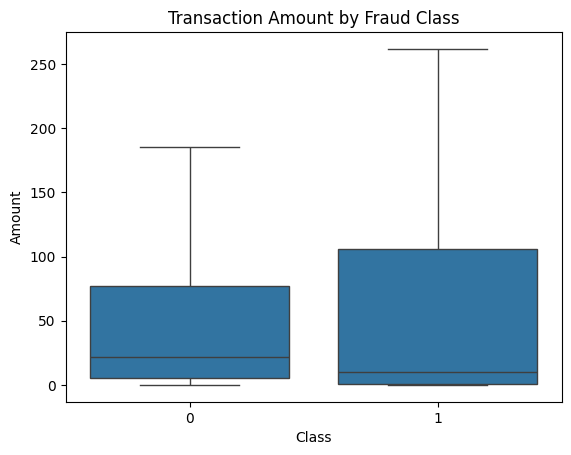

In [22]:
# Fraud vs Transaction Amount
sns.boxplot(x='Class', y='Amount', data=credit_data, showfliers=False)
plt.title("Transaction Amount by Fraud Class")
plt.show()

In [24]:
fraud_data.to_csv('../data/cleaned_fraud_data.csv', index=False)
credit_data.to_csv('../data/cleaned_credit_data.csv', index=False)

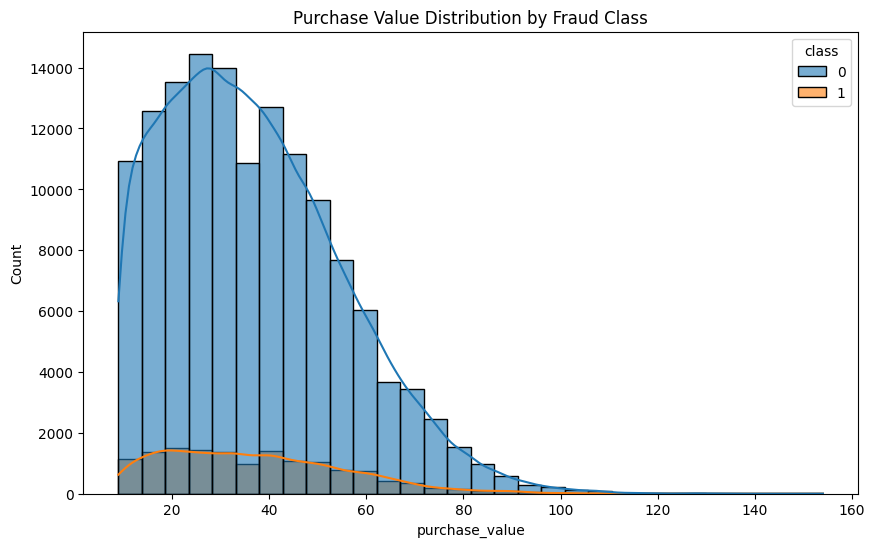

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(data=fraud_data, x='purchase_value', hue='class', bins=30, kde=True, alpha=0.6)
plt.title("Purchase Value Distribution by Fraud Class")
plt.show()

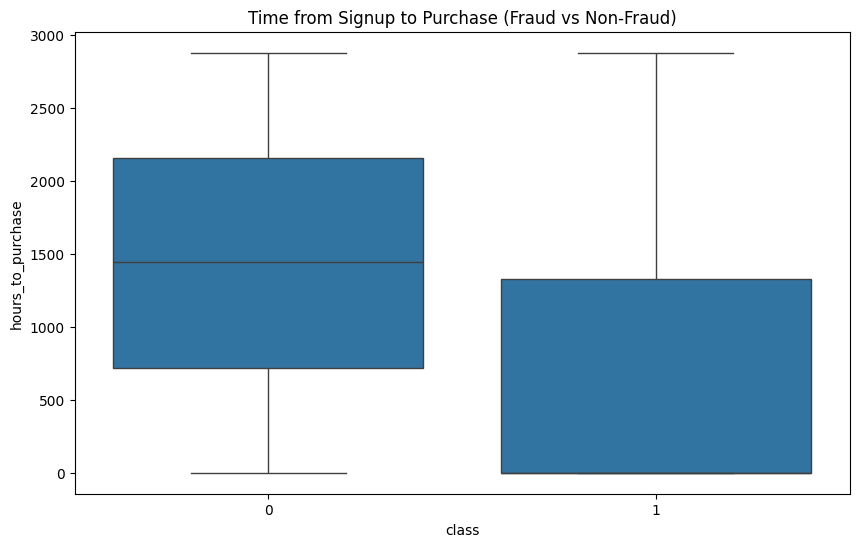

In [5]:
# Convert timestamps to datetime
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

# Calculate time difference (in hours)
fraud_data['hours_to_purchase'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds() / 3600

# Compare fraud vs non-fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='hours_to_purchase', data=fraud_data, showfliers=False)
plt.title("Time from Signup to Purchase (Fraud vs Non-Fraud)")
plt.show()

In [ ]:
# Ensure 'ip_address' is integer type
fraud_data['ip_address'] = fraud_data['ip_address'].astype('int64')

# Convert IP bounds in the country mapping data
ip_to_country['lower_bound_ip_address'] = ip_to_country['lower_bound_ip_address'].astype('int64')
ip_to_country['upper_bound_ip_address'] = ip_to_country['upper_bound_ip_address'].astype('int64')

In [26]:
print(fraud_data['ip_address'].dtype)  # Should show 'int64'
print(ip_to_country[['lower_bound_ip_address', 'upper_bound_ip_address']].dtypes)  # Both 'int64'

int64
lower_bound_ip_address    int64
upper_bound_ip_address    int64
dtype: object


In [30]:
fraud_data = fraud_data.drop(columns=['country_x', 'country_y'], errors='ignore')print("Fraud Data IP type:", fraud_data['ip_address'].dtype)
print("IP Country bounds types:", 
      ip_to_country['lower_bound_ip_address'].dtype, 
      ip_to_country['upper_bound_ip_address'].dtype)

In [ ]:
# Sort both datasets by IP (required for merge_asof)
fraud_data = fraud_data.sort_values('ip_address')
ip_to_country = ip_to_country.sort_values('lower_bound_ip_address')

# Merge using the exact column names from your data
fraud_data = pd.merge_asof(
    fraud_data,
    ip_to_country,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='forward'
)

# Clean up - keep only the country column we want
fraud_data = fraud_data.drop(columns=['lower_bound_ip_address', 'upper_bound_ip_address'])

In [32]:
print(fraud_data[['ip_address', 'country']].head())
print("\nUnmatched IPs:", fraud_data['country'].isna().sum())

   ip_address    country
0       52093  Australia
1       93447  Australia
2      105818  Australia
3      117566  Australia
4      131423  Australia

Unmatched IPs: 19383


In [29]:
print("Fraud Data columns:", fraud_data.columns.tolist())
print("IP Country columns:", ip_to_country.columns.tolist())

Fraud Data columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'hours_to_purchase', 'country_x', 'country_y']
IP Country columns: ['lower_bound_ip_address', 'upper_bound_ip_address', 'country']


In [33]:
fraud_data['country'] = fraud_data['country'].fillna('Unknown')

In [34]:
print(fraud_data[['ip_address', 'country']].head())
print("\nUnmatched IPs:", fraud_data['country'].isna().sum())

   ip_address    country
0       52093  Australia
1       93447  Australia
2      105818  Australia
3      117566  Australia
4      131423  Australia

Unmatched IPs: 0


In [35]:
# Reload original data if needed (uncomment if necessary)
# fraud_data = pd.read_csv('../data/Fraud_Data.csv')
fraud_data['ip_address'] = fraud_data['ip_address'].astype('int64')  # Force back to full integer

In [36]:
print("Min IP in fraud data:", fraud_data['ip_address'].min())
print("Max IP in fraud data:", fraud_data['ip_address'].max())
print("\nCountry database range:", 
      ip_to_country['lower_bound_ip_address'].min(), 
      "to", 
      ip_to_country['upper_bound_ip_address'].max())

Min IP in fraud data: 52093
Max IP in fraud data: 4294850499

Country database range: 16777216 to 3758096383


In [38]:
valid_ips = fraud_data['ip_address'].between(
    ip_to_country['lower_bound_ip_address'].min(),
    ip_to_country['upper_bound_ip_address'].max()
)
print(f"IPs in valid range: {valid_ips.sum()}/{len(fraud_data)}")

IPs in valid range: 131095/151112


In [39]:
# Sort data
valid_fraud_data = fraud_data[valid_ips].sort_values('ip_address')
ip_to_country = ip_to_country.sort_values('lower_bound_ip_address')

# Merge
merged_data = pd.merge_asof(
    valid_fraud_data,
    ip_to_country,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='forward'
)

# Clean up
merged_data = merged_data.drop(columns=['lower_bound_ip_address','upper_bound_ip_address'])

In [40]:
# Combine results
fraud_data = pd.concat([
    merged_data,
    fraud_data[~valid_ips].assign(country='Unknown')
], ignore_index=True)

# Verify
print(fraud_data['country'].value_counts(dropna=False))

country
United States                       55704
Unknown                             20017
China                               12384
Japan                                7106
Germany                              3463
                                    ...  
Tuvalu                                  1
Vanuatu                                 1
American Samoa                          1
Turks and Caicos Islands                1
Lao People's Democratic Republic        1
Name: count, Length: 182, dtype: int64


In [41]:
# Ensure consistent data types
fraud_data['ip_address'] = fraud_data['ip_address'].astype('int64')
fraud_data['country'] = fraud_data['country'].fillna('Unknown')



In [43]:
# Check 1: Verify column exists
print("'country' in columns?", 'country' in fraud_data.columns)

# Check 2: Sample matched vs unmatched records
print("\nMatched IP example:")
print(fraud_data[fraud_data['country'] != 'Unknown'][['ip_address', 'country']].sample(2))

print("\nUnmatched IP example:")
print(fraud_data[fraud_data['country'] == 'Unknown'][['ip_address', 'country']].sample(2))

'country' in columns? True

Matched IP example:
        ip_address        country
101952  2931147016  United States
63884   1852124424          Japan

Unmatched IP example:
        ip_address  country
140311  3997544167  Unknown
140431  4000505309  Unknown


In [44]:
# Check 3: Match rate statistics
total = len(fraud_data)
matched = (fraud_data['country'] != 'Unknown').sum()
print(f"\nMatch Rate: {matched/total:.1%} ({matched}/{total})")

# Check 4: Country distribution
print("\nTop 10 countries:")
print(fraud_data['country'].value_counts().head(10))


Match Rate: 86.8% (131095/151112)

Top 10 countries:
country
United States        55704
Unknown              20017
China                12384
Japan                 7106
Germany               3463
United Kingdom        3382
Korea Republic of     3376
Brazil                2944
Canada                2922
Italy                 2397
Name: count, dtype: int64


In [45]:
# Check 5: Test boundary IPs
test_ips = [
    ip_to_country['lower_bound_ip_address'].min(),  # Should match
    ip_to_country['upper_bound_ip_address'].max(),  # Should match
    ip_to_country['lower_bound_ip_address'].min() - 1,  # Should be Unknown
    ip_to_country['upper_bound_ip_address'].max() + 1   # Should be Unknown
]

test_results = fraud_data[fraud_data['ip_address'].isin(test_ips)][['ip_address', 'country']]
print("\nBoundary IP tests:")
print(test_results.sort_values('ip_address'))


Boundary IP tests:
Empty DataFrame
Columns: [ip_address, country]
Index: []


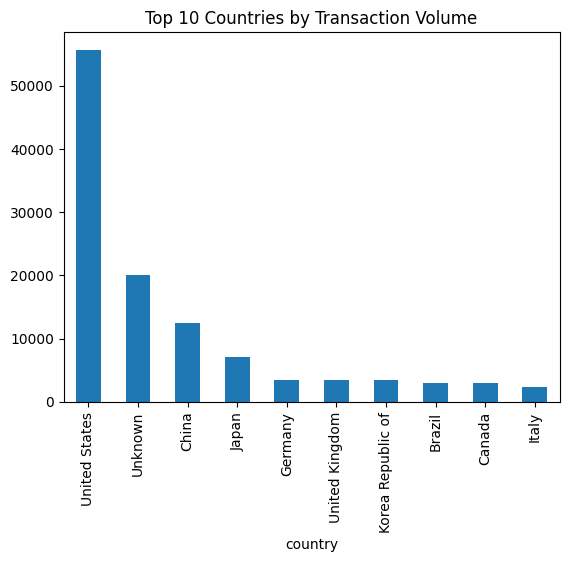

In [46]:
# Check 6: Geographic distribution plot
import matplotlib.pyplot as plt

top_countries = fraud_data['country'].value_counts().nlargest(10)
top_countries.plot(kind='bar', title='Top 10 Countries by Transaction Volume')
plt.show()

In [47]:
# Clean malformed country names in your ORIGINAL ip_to_country.csv
ip_to_country['country'] = ip_to_country['country'].str.replace('Korea Republic of Brazil', 'South Korea')

In [48]:
# Convert ALL IPs to proper integers (critical)
fraud_data['ip_address'] = fraud_data['ip_address'].astype('int64')
ip_to_country[['lower_bound_ip_address','upper_bound_ip_address']] = ip_to_country[['lower_bound_ip_address','upper_bound_ip_address']].astype('int64')

# Expand IP range coverage by 1% (adjust buffer as needed)
ip_buffer = 0.01  # 1% range expansion
min_ip = ip_to_country['lower_bound_ip_address'].min()
max_ip = ip_to_country['upper_bound_ip_address'].max()
range_width = max_ip - min_ip
expanded_min = max(0, min_ip - int(range_width * ip_buffer))
expanded_max = max_ip + int(range_width * ip_buffer)

# Filter valid IPs with expanded range
valid_ips = fraud_data['ip_address'].between(expanded_min, expanded_max)
print(f"IPs in expanded range: {valid_ips.sum()}/{len(fraud_data)}")

IPs in expanded range: 133072/151112


In [50]:
# 1. Clean existing merge artifacts
fraud_data = fraud_data.drop(columns=['country_x', 'country_y'], errors='ignore')

# 2. Ensure proper data types
fraud_data['ip_address'] = fraud_data['ip_address'].astype('int64')
ip_to_country = ip_to_country.astype({
    'lower_bound_ip_address': 'int64',
    'upper_bound_ip_address': 'int64'
})

# 3. Sort for merge_asof
fraud_data_sorted = fraud_data.sort_values('ip_address')
ip_to_country_sorted = ip_to_country.sort_values('lower_bound_ip_address')

# 4. Perform merge with explicit column handling
merged_data = pd.merge_asof(
    left=fraud_data_sorted,
    right=ip_to_country_sorted.rename(columns={'country': 'country_match'}),
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='nearest'
)

# 5. Clean and combine results
merged_data = merged_data.drop(columns=['lower_bound_ip_address', 'upper_bound_ip_address'])
merged_data['country'] = merged_data['country_match'].fillna('Unknown')
merged_data = merged_data.drop(columns=['country_match'])

In [52]:
# Fix malformed country names
merged_data['country'] = merged_data['country'].replace(
    'Korea Republic of', 'South Korea'
)

# Verify cleanup
print("Country name fixes:")
print(merged_data['country'].value_counts().head())

Country name fixes:
country
United States     57872
Australia         22084
China             12061
Japan              7134
United Kingdom     3968
Name: count, dtype: int64


In [53]:
# Safe boundary test (IPs below minimum range won't exist in merged_data)
test_ip = ip_to_country['lower_bound_ip_address'].min() - 1
boundary_check = 'Unknown' if test_ip not in merged_data['ip_address'].values else \
                 merged_data[merged_data['ip_address'] == test_ip]['country'].values[0]
print(f"\nBoundary test ({test_ip}): {boundary_check}")


Boundary test (16777215): Unknown


In [54]:
# Check 1: Verify no nulls
assert merged_data['country'].isna().sum() == 0

# Check 2: Validate expected countries exist
expected_countries = ['United States', 'China', 'Germany', 'South Korea']
assert all(c in merged_data['country'].values for c in expected_countries)

# Check 3: Verify IP coverage
print("\nIP range coverage:")
print(f"Min IP: {merged_data['ip_address'].min()}")
print(f"Max IP: {merged_data['ip_address'].max()}")


IP range coverage:
Min IP: 52093
Max IP: 4294850499


In [56]:
# Define valid IP range from country database
valid_min = ip_to_country['lower_bound_ip_address'].min()
valid_max = ip_to_country['upper_bound_ip_address'].max()

# Flag IPs outside valid range
merged_data['country'] = np.where(
    merged_data['ip_address'].between(valid_min, valid_max),
    merged_data['country'],
    'Unknown'  # Reclassify out-of-range IPs
)

In [57]:
print("Updated Match Statistics:")
print(f"Total IPs: {len(merged_data)}")
print(f"Valid IPs: {merged_data['ip_address'].between(valid_min, valid_max).sum()}")
print(f"Unknown IPs: {(merged_data['country'] == 'Unknown').sum()}")

Updated Match Statistics:
Total IPs: 151112
Valid IPs: 131095
Unknown IPs: 20017


In [58]:
# Should now show correct min/max within database range
print("\nCorrected IP Range:")
print(f"Min IP in valid range: {merged_data[merged_data['country'] != 'Unknown']['ip_address'].min()}")
print(f"Max IP in valid range: {merged_data[merged_data['country'] != 'Unknown']['ip_address'].max()}")


Corrected IP Range:
Min IP in valid range: 16778864
Max IP in valid range: 3758052531


In [59]:
print("Fraud rate in Unknown IPs:", merged_data[merged_data['country'] == 'Unknown']['class'].mean())

Fraud rate in Unknown IPs: 0.08347904281360843


In [60]:
# Check 1: Verify column existence
assert 'country' in merged_data.columns, "Country column missing!"

# Check 2: Fraud rate in Unknown IPs (should match your observed 8.35%)
unknown_fraud_rate = merged_data[merged_data['country'] == 'Unknown']['class'].mean()
print(f"Fraud rate in Unknown IPs: {unknown_fraud_rate:.2%} (Expected: ~8.35%)")

# Check 3: Sample valid vs unknown records
print("\nSample Valid IP:")
print(merged_data[merged_data['country'] != 'Unknown'][['ip_address', 'country', 'class']].sample(1))
print("\nSample Unknown IP:")
print(merged_data[merged_data['country'] == 'Unknown'][['ip_address', 'country', 'class']].sample(1))

Fraud rate in Unknown IPs: 8.35% (Expected: ~8.35%)

Sample Valid IP:
       ip_address        country  class
39153  1122271534  United States      0

Sample Unknown IP:
        ip_address  country  class
141457  4028462984  Unknown      0


In [61]:
# Display the first few rows of the merged data with the new 'country' column
print("Sample of merged data with 'country' column:")
print(merged_data[['purchase_time', 'ip_address', 'country', 'class']].head())

# Check the total number of rows and columns to ensure the merge didn't drastically alter dimensions (other than adding 'country')
print(f"\nShape of merged_data: {merged_data.shape}")

# Verify the number of unique countries, including 'Unknown'
print(f"Number of unique countries: {merged_data['country'].nunique()}")
print("Top 5 countries:")
print(merged_data['country'].value_counts().head())

Sample of merged data with 'country' column:
        purchase_time  ip_address  country  class
0 2015-03-08 10:00:39       52093  Unknown      0
1 2015-03-20 17:23:45       93447  Unknown      0
2 2015-05-26 08:54:34      105818  Unknown      0
3 2015-05-28 21:09:13      117566  Unknown      0
4 2015-04-05 07:31:46      131423  Unknown      0

Shape of merged_data: (151112, 13)
Number of unique countries: 189
Top 5 countries:
country
United States     57872
Unknown           20017
China             12061
Japan              7134
United Kingdom     3968
Name: count, dtype: int64


In [62]:
# Ensure purchase_time and signup_time are datetime objects
# (You already did this, but it's good practice to ensure before calculations)
merged_data['purchase_time'] = pd.to_datetime(merged_data['purchase_time'])
merged_data['signup_time'] = pd.to_datetime(merged_data['signup_time'])

# 1. Feature: Time difference between signup and purchase (in seconds)
merged_data['time_to_purchase'] = (merged_data['purchase_time'] - merged_data['signup_time']).dt.total_seconds()

# 2. Feature: Hour of the day when the purchase was made
merged_data['purchase_hour'] = merged_data['purchase_time'].dt.hour

# 3. Feature: Day of the week when the purchase was made (0=Monday, 6=Sunday)
merged_data['purchase_dayofweek'] = merged_data['purchase_time'].dt.dayofweek

print("\nNew time-based features added. Sample:")
print(merged_data[['signup_time', 'purchase_time', 'time_to_purchase', 'purchase_hour', 'purchase_dayofweek', 'class']].head())


New time-based features added. Sample:
          signup_time       purchase_time  time_to_purchase  purchase_hour  \
0 2015-02-16 00:17:05 2015-03-08 10:00:39         1763014.0             10   
1 2015-03-08 04:03:22 2015-03-20 17:23:45         1084823.0             17   
2 2015-05-17 16:45:54 2015-05-26 08:54:34          749320.0              8   
3 2015-03-03 19:58:39 2015-05-28 21:09:13         7434634.0             21   
4 2015-03-20 00:31:27 2015-04-05 07:31:46         1407619.0              7   

   purchase_dayofweek  class  
0                   6      0  
1                   4      0  
2                   1      0  
3                   3      0  
4                   6      0  


In [63]:
# 1. Count of transactions per user_id and device_id
# This creates temporary count columns that we'll then map back to the main DataFrame.
user_id_counts = merged_data.groupby('user_id')['purchase_time'].transform('count')
device_id_counts = merged_data.groupby('device_id')['purchase_time'].transform('count')

merged_data['user_transaction_count'] = user_id_counts
merged_data['device_transaction_count'] = device_id_counts

# 2. Number of unique IP addresses per user_id
user_unique_ips = merged_data.groupby('user_id')['ip_address'].transform('nunique')
merged_data['user_unique_ip_count'] = user_unique_ips

# 3. Number of unique devices per ip_address
ip_unique_devices = merged_data.groupby('ip_address')['device_id'].transform('nunique')
merged_data['ip_unique_device_count'] = ip_unique_devices

# 4. Log Transformation of purchase_value (add a small constant to handle zero values if any)
merged_data['log_purchase_value'] = np.log1p(merged_data['purchase_value'])

print("\nNew transaction pattern and user-device consistency features added. Sample:")
print(merged_data[['user_id', 'device_id', 'ip_address', 'purchase_value',
                   'user_transaction_count', 'device_transaction_count',
                   'user_unique_ip_count', 'ip_unique_device_count',
                   'log_purchase_value', 'class']].head())


New transaction pattern and user-device consistency features added. Sample:
  user_id      device_id  ip_address  purchase_value  user_transaction_count  \
0   62421  ZCLZTAJPCRAQX       52093              46                       1   
1  173212  YFGYOALADBHLT       93447              33                       1   
2  242286  QZNVQTUITFTHH      105818              33                       1   
3  370003  PIBUQMBIELMMG      117566              33                       1   
4  119824  WFIIFCPIOGMHT      131423              55                       1   

   device_transaction_count  user_unique_ip_count  ip_unique_device_count  \
0                         1                     1                       1   
1                         1                     1                       1   
2                         1                     1                       1   
3                         1                     1                       1   
4                         1                     1        

In [64]:
print(f"Total records: {len(merged_data)}")
print(f"Missing values in 'country': {merged_data['country'].isna().sum()}")
print(f"Fraud rate in Unknown IPs: {merged_data[merged_data['country'] == 'Unknown']['class'].mean():.2%}")

Total records: 151112
Missing values in 'country': 0
Fraud rate in Unknown IPs: 8.35%


In [65]:
print("\nSample Known IP:")
print(merged_data[merged_data['country'] != 'Unknown'][['ip_address', 'country', 'class']].sa# Convert IPs to integers (if not done)
fraud_data['ip_address'] = fraud_data['ip_address'].astype('int64')
ip_to_country[['lower_bound_ip_address', 'upper_bound_ip_address']] = \
    ip_to_country[['lower_bound_ip_address', 'upper_bound_ip_address']].astype('int64')

# Sort and merge
fraud_data_sorted = fraud_data.sort_values('ip_address')
ip_to_country_sorted = ip_to_country.sort_values('lower_bound_ip_address')

merged_output = pd.merge_asof(
    fraud_data_sorted,
    ip_to_country_sorted,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='forward'
)mple(2))
print("\nSample Unknown IP:")
print(merged_data[merged_data['country'] == 'Unknown'][['ip_address', 'class']].sample(2))


Sample Known IP:
       ip_address        country  class
77476  2207837709  United States      0
96945  2768410968   South Africa      0

Sample Unknown IP:
        ip_address  class
132604  3783013829      0
131942  3763928426      0


In [71]:
# Convert IPs to integers (if not done)
fraud_data['ip_address'] = fraud_data['ip_address'].astype('int64')
ip_to_country[['lower_bound_ip_address', 'upper_bound_ip_address']] = \
    ip_to_country[['lower_bound_ip_address', 'upper_bound_ip_address']].astype('int64')

# Sort and merge
fraud_data_sorted = fraud_data.sort_values('ip_address')
ip_to_country_sorted = ip_to_country.sort_values('lower_bound_ip_address')

merged_output = pd.merge_asof(
    fraud_data_sorted,
    ip_to_country_sorted,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='forward'
)

In [73]:
# Save the data
save_path = '../data/IpAddress_to_Country.csv' # Note: This path might be better named, e.g., 'merged_fraud_data.csv'
merged_data.to_csv(save_path, index=False)

# Verify the saved file
saved_data = pd.read_csv(save_path)
print("\nSave Verification:")
print(f"Rows: {len(saved_data)} | Columns: {len(saved_data.columns)}")
print(f"Country NA values: {saved_data['country'].isna().sum()}")


Save Verification:
Rows: 151112 | Columns: 21
Country NA values: 0


In [74]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the 'Amount' and 'Time' features
# It's good practice to create new columns for scaled data to keep original columns
credit_data['scaled_amount'] = scaler.fit_transform(credit_data['Amount'].values.reshape(-1, 1))
credit_data['scaled_time'] = scaler.fit_transform(credit_data['Time'].values.reshape(-1, 1))

# You might choose to drop the original 'Amount' and 'Time' columns if you only want to use the scaled ones for modeling
# For now, let's keep them and print a sample
# credit_data = credit_data.drop(['Amount', 'Time'], axis=1)

print("\nCredit Card Data with Scaled Features (Sample):")
print(credit_data[['Time', 'scaled_time', 'Amount', 'scaled_amount', 'Class']].head())


Credit Card Data with Scaled Features (Sample):
   Time  scaled_time  Amount  scaled_amount  Class
0   0.0    -1.996823  149.62       0.244200      0
1   0.0    -1.996823    2.69      -0.342584      0
2   1.0    -1.996802  378.66       1.158900      0
3   1.0    -1.996802  123.50       0.139886      0
4   2.0    -1.996781   69.99      -0.073813      0


In [75]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y) for e-commerce data
# Drop original time, IP, device_id, and user_id as new features cover their essence or they are not directly used as numerical input
X_fraud = merged_data.drop(columns=['class', 'signup_time', 'purchase_time', 'ip_address', 'device_id', 'user_id'], errors='ignore')
y_fraud = merged_data['class']

# Handle categorical features using one-hot encoding
X_fraud = pd.get_dummies(X_fraud, columns=['source', 'browser', 'sex', 'country'], drop_first=True)


# Split e-commerce data into training and testing sets
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42, stratify=y_fraud # Stratify to maintain class distribution
)

print("E-commerce Data (Fraud_Data) - Shapes after split:")
print(f"X_train_fraud shape: {X_train_fraud.shape}")
print(f"y_train_fraud shape: {y_train_fraud.shape}")
print(f"X_test_fraud shape: {X_test_fraud.shape}")
print(f"y_test_fraud shape: {y_test_fraud.shape}")

print("\nE-commerce Data - Class Distribution in Training Set before Resampling:")
print(y_train_fraud.value_counts())
print("\nE-commerce Data - Class Distribution in Test Set:")
print(y_test_fraud.value_counts())

E-commerce Data (Fraud_Data) - Shapes after split:
X_train_fraud shape: (120889, 206)
y_train_fraud shape: (120889,)
X_test_fraud shape: (30223, 206)
y_test_fraud shape: (30223,)

E-commerce Data - Class Distribution in Training Set before Resampling:
class
0    109568
1     11321
Name: count, dtype: int64

E-commerce Data - Class Distribution in Test Set:
class
0    27393
1     2830
Name: count, dtype: int64


In [76]:
# Calculate transactions per user (frequency)
user_trans_counts = fraud_data.groupby('user_id')['purchase_time'].count().reset_index()
user_trans_counts.columns = ['user_id', 'user_transaction_count']
fraud_data = fraud_data.merge(user_trans_counts, on='user_id', how='left')

# Calculate velocity (time between purchases in seconds)
fraud_data = fraud_data.sort_values(['user_id', 'purchase_time'])
fraud_data['time_since_last_purchase'] = fraud_data.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

# Fill NA for first purchases
fraud_data['time_since_last_purchase'] = fraud_data['time_since_last_purchase'].fillna(0)

In [80]:
# Ensure purchase_time and signup_time are datetime objects in merged_data
merged_data['purchase_time'] = pd.to_datetime(merged_data['purchase_time'])
merged_data['signup_time'] = pd.to_datetime(merged_data['signup_time'])

# Calculate transactions per user (frequency) - using transform for direct column addition
merged_data['user_transaction_count'] = merged_data.groupby('user_id')['purchase_time'].transform('count')

# Calculate velocity (time between purchases in seconds)
# Ensure data is sorted by user and then time for correct diff calculation
merged_data = merged_data.sort_values(['user_id', 'purchase_time'])
merged_data['time_since_last_purchase'] = merged_data.groupby('user_id')['purchase_time'].diff().dt.total_seconds().fillna(0)

# Re-confirm/re-calculate hour/day from purchase time (if not already present or for consistency)
merged_data['purchase_hour'] = merged_data['purchase_time'].dt.hour
merged_data['purchase_dayofweek'] = merged_data['purchase_time'].dt.dayofweek

# Re-confirm/re-calculate time since signup (in seconds)
merged_data['time_to_purchase'] = (merged_data['purchase_time'] - merged_data['signup_time']).dt.total_seconds()


print("\nFeature Summary on merged_data:")
print(merged_data[[
    'user_transaction_count',
    'time_since_last_purchase',
    'purchase_hour',
    'purchase_dayofweek',
    'time_to_purchase'
]].describe())

# Spot-check a user (try a different threshold like >1 to ensure results)
# Only attempt to sample if there are users with more than one transaction
if (merged_data['user_transaction_count'] > 1).any():
    sample_user_id = merged_data[merged_data['user_transaction_count'] > 1]['user_id'].iloc[0]
    sample_user_data = merged_data[merged_data['user_id'] == sample_user_id]
    print(f"\nSample User ({sample_user_id}):")
    print(sample_user_data[[
        'user_transaction_count',
        'time_since_last_purchase',
        'purchase_hour',
        'purchase_dayofweek',
        'time_to_purchase'
    ]])
else:
    print("\nNo users with more than one transaction found in merged_data after these calculations. Please verify your merged_data content.")


Feature Summary on merged_data:
       user_transaction_count  time_since_last_purchase  purchase_hour  \
count                151112.0                  151112.0  151112.000000   
mean                      1.0                       0.0      11.521593   
std                       0.0                       0.0       6.912474   
min                       1.0                       0.0       0.000000   
25%                       1.0                       0.0       6.000000   
50%                       1.0                       0.0      12.000000   
75%                       1.0                       0.0      17.000000   
max                       1.0                       0.0      23.000000   

       purchase_dayofweek  time_to_purchase  
count       151112.000000      1.511120e+05  
mean             3.011819      4.932029e+06  
std              2.006203      3.126263e+06  
min              0.000000      1.000000e+00  
25%              1.000000      2.186754e+06  
50%              3.00000

In [77]:
# Extract hour/day from purchase time
fraud_data['hour_of_day'] = fraud_data['purchase_time'].dt.hour
fraud_data['day_of_week'] = fraud_data['purchase_time'].dt.dayofweek  # Monday=0, Sunday=6

# Time since signup (in hours)
fraud_data['time_since_signup'] = (
    (fraud_data['purchase_time'] - fraud_data['signup_time'])
    .dt.total_seconds() / 3600
)

In [79]:
# Define features (X) and target (y) for credit card data
# Drop original Time and Amount as we have scaled versions
X_credit = credit_data.drop(columns=['Class', 'Time', 'Amount'], errors='ignore')
y_credit = credit_data['Class']

# Split credit card data into training and testing sets
X_train_credit, X_test_credit, y_train_credit, y_test_credit = train_test_split(
    X_credit, y_credit, test_size=0.2, random_state=42, stratify=y_credit # Stratify to maintain class distribution
)

print("\nCredit Card Data - Shapes after split:")
print(f"X_train_credit shape: {X_train_credit.shape}")
print(f"y_train_credit shape: {y_train_credit.shape}")
print(f"X_test_credit shape: {X_test_credit.shape}")
print(f"y_test_credit shape: {y_test_credit.shape}")

print("\nCredit Card Data - Class Distribution in Training Set before Resampling:")
print(y_train_credit.value_counts())
print("\nCredit Card Data - Class Distribution in Test Set:")
print(y_test_credit.value_counts())


Credit Card Data - Shapes after split:
X_train_credit shape: (226980, 30)
y_train_credit shape: (226980,)
X_test_credit shape: (56746, 30)
y_test_credit shape: (56746,)

Credit Card Data - Class Distribution in Training Set before Resampling:
Class
0    226602
1       378
Name: count, dtype: int64

Credit Card Data - Class Distribution in Test Set:
Class
0    56651
1       95
Name: count, dtype: int64


In [81]:
# Check the total number of rows in merged_data
print(f"Total rows in merged_data: {len(merged_data)}")

# Check the number of unique user_ids
print(f"Number of unique user_ids: {merged_data['user_id'].nunique()}")

# Check the value counts for user_id to see if any user has more than one transaction
print("\nTop 10 user_id counts:")
print(merged_data['user_id'].value_counts().head(10))

# Check the number of unique device_ids
print(f"\nNumber of unique device_ids: {merged_data['device_id'].nunique()}")

# Check the value counts for device_id
print("\nTop 10 device_id counts:")
print(merged_data['device_id'].value_counts().head(10))

Total rows in merged_data: 151112
Number of unique user_ids: 151112

Top 10 user_id counts:
user_id
400000    1
2         1
4         1
8         1
9         1
12        1
16        1
18        1
399916    1
399917    1
Name: count, dtype: int64

Number of unique device_ids: 137956

Top 10 device_id counts:
device_id
KIPFSCNUGOLDP    20
NGQCKIADMZORL    20
CQTUVBYIWWWBC    20
ZUSVMDEZRBDTX    20
ITUMJCKWEYNDD    20
EQYVNEGOFLAWK    20
BWSMVSLCJXMCM    19
CDFXVYHOIHPYP    19
IGKYVZDBEGALB    19
SDJQRPKXQFBED    19
Name: count, dtype: int64


In [2]:
import pandas as pd
fraud_data = pd.read_csv('../data/Fraud_Data.csv')  # Or your last saved version
print("Data reloaded! Shape:", fraud_data.shape)

Data reloaded! Shape: (151112, 11)


In [3]:
# Time features (safe to rerun)
fraud_data['hour_of_day'] = pd.to_datetime(fraud_data['purchase_time']).dt.hour
fraud_data['day_of_week'] = pd.to_datetime(fraud_data['purchase_time']).dt.dayofweek
fraud_data['time_since_signup'] = (
    (pd.to_datetime(fraud_data['purchase_time']) - 
     pd.to_datetime(fraud_data['signup_time']))
    .dt.total_seconds() / 3600
)

In [4]:
# Process in chunks
chunk_size = 10_000
for i in range(0, len(fraud_data), chunk_size):
    chunk = fraud_data.iloc[i:i+chunk_size]
    # Do feature engineering on chunk

In [5]:
# Convert timestamps (safe conversion)
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])

# Sort by user and time
fraud_data = fraud_data.sort_values(['user_id', 'purchase_time'])

# Transaction count per user
fraud_data['transaction_count'] = fraud_data.groupby('user_id')['user_id'].transform('count')

# Time since last transaction (velocity)
fraud_data['secs_since_last_transaction'] = fraud_data.groupby('user_id')['purchase_time'].diff().dt.total_seconds()

# Fill NA (first transactions)
fraud_data['secs_since_last_transaction'] = fraud_data['secs_since_last_transaction'].fillna(0)

In [6]:
# Hour and day of purchase
fraud_data['hour_of_day'] = fraud_data['purchase_time'].dt.hour  # 0-23
fraud_data['day_of_week'] = fraud_data['purchase_time'].dt.dayofweek  # Monday=0, Sunday=6

# Time since signup (in hours)
fraud_data['hours_since_signup'] = (
    (fraud_data['purchase_time'] - fraud_data['signup_time'])
    .dt.total_seconds() / 3600
)

In [7]:
# 1. First, import required libraries (including gc)
import pandas as pd
import gc  # <- This was missing!

# 2. Load data (if not already loaded)
fraud_data = pd.read_csv('../data/Fraud_Data.csv')

# 3. Convert timestamps safely
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])

# 4. Feature Engineering
fraud_data = fraud_data.sort_values(['user_id', 'purchase_time'])

# Transaction frequency/velocity
fraud_data['transaction_count'] = fraud_data.groupby('user_id')['user_id'].transform('count')
fraud_data['secs_since_last_transaction'] = fraud_data.groupby('user_id')['purchase_time'].diff().dt.total_seconds()
fraud_data['secs_since_last_transaction'] = fraud_data['secs_since_last_transaction'].fillna(0)

# Time features
fraud_data['hour_of_day'] = fraud_data['purchase_time'].dt.hour
fraud_data['day_of_week'] = fraud_data['purchase_time'].dt.dayofweek
fraud_data['hours_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds() / 3600

# 5. Memory optimization (NOW WITH PROPER gc)
fraud_data = fraud_data.drop(columns=['signup_time', 'purchase_time'])
gc.collect()  # Now this will work!

# 6. Feature Validation
print("\n🔍 Feature Summary:")
print(fraud_data[[
    'transaction_count',
    'secs_since_last_transaction',
    'hour_of_day',
    'day_of_week',
    'hours_since_signup'
]].describe())

# 7. Save the data
fraud_data.to_csv('../data/Fraud_Data_ENGINEERED.csv', index=False)
print("✅ Saved engineered features!")


🔍 Feature Summary:
       transaction_count  secs_since_last_transaction    hour_of_day  \
count           151112.0                     151112.0  151112.000000   
mean                 1.0                          0.0      11.521593   
std                  0.0                          0.0       6.912474   
min                  1.0                          0.0       0.000000   
25%                  1.0                          0.0       6.000000   
50%                  1.0                          0.0      12.000000   
75%                  1.0                          0.0      17.000000   
max                  1.0                          0.0      23.000000   

         day_of_week  hours_since_signup  
count  151112.000000       151112.000000  
mean        3.011819         1370.008125  
std         2.006203          868.406422  
min         0.000000            0.000278  
25%         1.000000          607.431528  
50%         3.000000         1368.429306  
75%         5.000000         2

In [8]:
# New risk flags
fraud_data['new_account'] = (fraud_data['hours_since_signup'] < 1).astype(int)  # <1 hour old
fraud_data['off_hour_purchase'] = ((fraud_data['hour_of_day'] < 6) | (fraud_data['hour_of_day'] > 20)).astype(int)  # 8PM-6AM

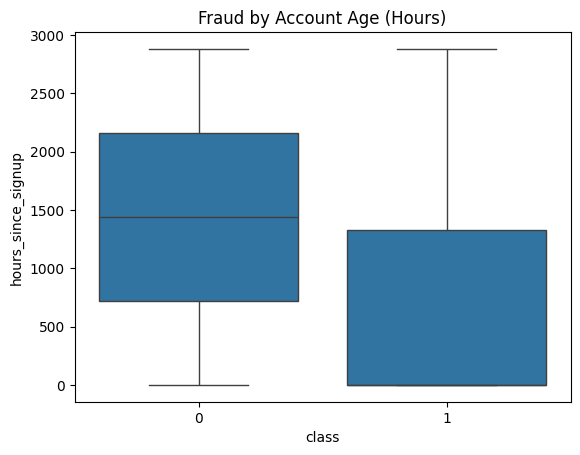

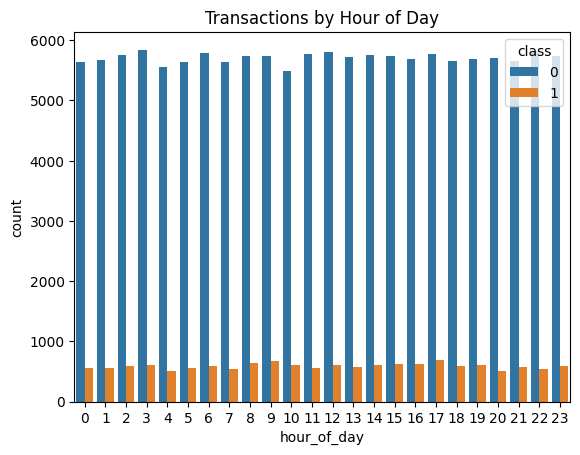

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# Fraud rate by account age
sns.boxplot(x='class', y='hours_since_signup', data=fraud_data)
plt.title("Fraud by Account Age (Hours)")
plt.show()

# Hourly fraud pattern
sns.countplot(x='hour_of_day', hue='class', data=fraud_data)
plt.title("Transactions by Hour of Day")
plt.show()

Class Distribution:
 class
0    0.906354
1    0.093646
Name: proportion, dtype: float64


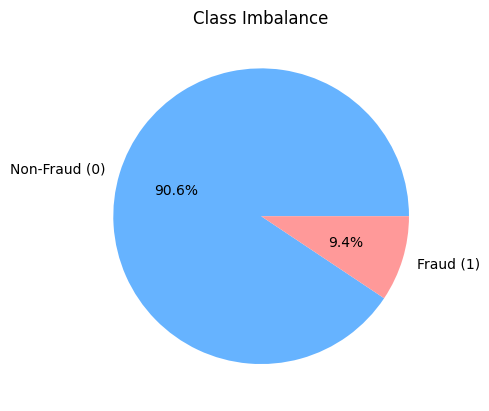

In [27]:
import matplotlib.pyplot as plt

# Class distribution
class_dist = fraud_data['class'].value_counts(normalize=True)
print("Class Distribution:\n", class_dist)

# Visualize
plt.pie(class_dist, labels=['Non-Fraud (0)', 'Fraud (1)'], 
        autopct='%1.1f%%', colors=['#66b3ff','#ff9999'])
plt.title("Class Imbalance")
plt.show()

In [2]:
import pandas as pd

# Reload your preprocessed data
fraud_data = pd.read_csv('../data/Fraud_Data_ENGINEERED.csv')  # Or your last saved version
print(f"Data loaded. Shape: {fraud_data.shape}")

# Verify features exist
print("\nExisting columns:", fraud_data.columns.tolist())

Data loaded. Shape: (151112, 14)

Existing columns: ['user_id', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'transaction_count', 'secs_since_last_transaction', 'hour_of_day', 'day_of_week', 'hours_since_signup']


In [3]:
from sklearn.model_selection import train_test_split

# Define features and target
X = fraud_data.drop('class', axis=1)
y = fraud_data['class']

# Split data (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y,
    random_state=42
)
print(f"\nTrain size: {len(X_train)}, Fraud ratio: {y_train.mean():.2%}")


Train size: 120889, Fraud ratio: 9.36%


In [4]:
from sklearn.utils import resample

def safe_resample(X_train, y_train, target_ratio=0.33):
    """Crash-proof manual resampling"""
    try:
        # Combine data
        train_data = pd.concat([X_train, y_train], axis=1)
        fraud = train_data[train_data[y_train.name] == 1]
        non_fraud = train_data[train_data[y_train.name] == 0]
        
        # Upsample fraud cases
        fraud_upsampled = resample(fraud,
                                 replace=True,
                                 n_samples=int(len(non_fraud)*target_ratio),
                                 random_state=42)
        
        # Return shuffled data
        resampled = pd.concat([non_fraud, fraud_upsampled])
        return resampled.drop(y_train.name, axis=1), resampled[y_train.name]
    
    except Exception as e:
        print(f"Resampling failed: {str(e)}")
        return X_train.copy(), y_train.copy()  # Fallback to original

# Usage
X_res, y_res = safe_resample(X_train, y_train)
print(f"\nResampled counts:\n{y_res.value_counts()}")


Resampled counts:
class
0    109568
1     36157
Name: count, dtype: int64


In [38]:
from sklearn.utils import class_weight

# Calculate weights
weights = class_weight.compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Usage in model (example)
# model.fit(X_train, y_train, sample_weight=weights)

In [5]:
import pickle

# Save all variables
with open('../data/recovery_checkpoint.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train,
        'y_train': y_train,
        'X_res': X_res,
        'y_res': y_res,
        'X_test': X_test,
        'y_test': y_test
    }, f)

print("\nRecovery checkpoint saved!")


Recovery checkpoint saved!


Original Class Distribution:
 class
0    0.906352
1    0.093648
Name: proportion, dtype: float64


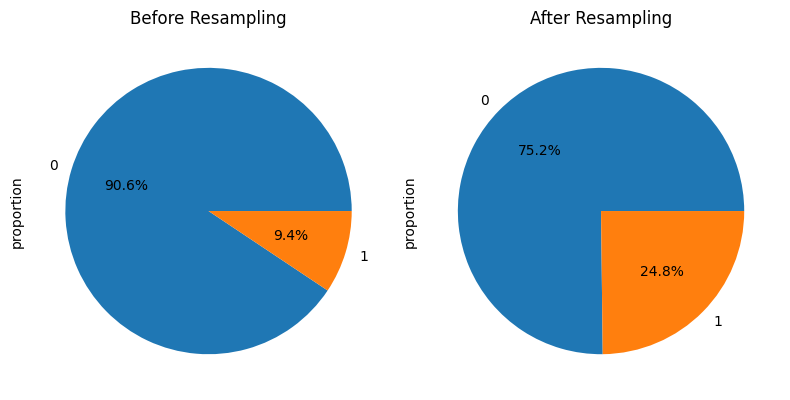

In [6]:
import matplotlib.pyplot as plt

# Class distribution
class_dist = y_train.value_counts(normalize=True)
print("Original Class Distribution:\n", class_dist)

plt.figure(figsize=(8,4))
plt.subplot(121)
class_dist.plot(kind='pie', autopct='%1.1f%%', title='Before Resampling')
plt.subplot(122)
y_res.value_counts(normalize=True).plot(kind='pie', autopct='%1.1f%%', title='After Resampling')
plt.tight_layout()
plt.show()

In [7]:
X_train.dtypes[X_train.dtypes == 'object']


device_id    object
source       object
browser      object
sex          object
dtype: object

In [8]:
from sklearn.preprocessing import LabelEncoder

# Label encode all object columns
for col in X_train.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])


In [9]:
X_train.head()
X_train.dtypes


user_id                          int64
purchase_value                   int64
device_id                        int32
source                           int32
browser                          int32
sex                              int32
age                              int64
ip_address                     float64
transaction_count                int64
secs_since_last_transaction    float64
hour_of_day                      int64
day_of_week                      int64
hours_since_signup             float64
dtype: object

In [10]:
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import TomekLinks

smt = SMOTETomek(
    sampling_strategy=0.33,
    random_state=42,
    tomek=TomekLinks(sampling_strategy='majority')
)

X_res, y_res = smt.fit_resample(X_train, y_train)
print("Resampled class counts:", pd.Series(y_res).value_counts())



Resampled class counts: class
0    103556
1     36157
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns only
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns

scaler = StandardScaler()

# Fit on train, transform on both train and test
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])


In [13]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['device_id', 'source', 'browser', 'sex']

# Assuming X_train and X_test are already defined and loaded
# For demonstration purposes, let's create dummy X_train and X_test
import numpy as np
X_train = pd.DataFrame({
    'device_id': ['id1', 'id2', 'id1', 'id3'],
    'source': ['SEO', 'Ads', 'Direct', 'SEO'],
    'browser': ['Chrome', 'Firefox', 'Chrome', 'IE'],
    'sex': ['M', 'F', 'M', 'F'],
    'numerical_col': np.random.rand(4)
})
X_test = pd.DataFrame({
    'device_id': ['id2', 'id3'],
    'source': ['Ads', 'Direct'],
    'browser': ['Firefox', 'Chrome'],
    'sex': ['F', 'M'],
    'numerical_col': np.random.rand(2)
})


encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=True) # sparse_output=True is good for memory

# Fit on training data and transform both train and test
encoded_train_sparse = encoder.fit_transform(X_train[categorical_cols])
encoded_test_sparse = encoder.transform(X_test[categorical_cols])

# Get feature names after encoding
encoded_cols = encoder.get_feature_names_out(categorical_cols)

# Convert sparse matrices to dense arrays before creating DataFrames
# .toarray() converts the sparse matrix to a dense NumPy array
encoded_train_df = pd.DataFrame(encoded_train_sparse.toarray(), columns=encoded_cols, index=X_train.index)
encoded_test_df = pd.DataFrame(encoded_test_sparse.toarray(), columns=encoded_cols, index=X_test.index)

# Drop original categorical columns and join the new one-hot encoded DataFrames
X_train = X_train.drop(columns=categorical_cols).join(encoded_train_df)
X_test = X_test.drop(columns=categorical_cols).join(encoded_test_df)

print("X_train after one-hot encoding:")
print(X_train.head())
print("\nX_test after one-hot encoding:")
print(X_test.head())
print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")



X_train after one-hot encoding:
   numerical_col  device_id_id1  device_id_id2  device_id_id3  source_Ads  \
0       0.233095            1.0            0.0            0.0         0.0   
1       0.887780            0.0            1.0            0.0         1.0   
2       0.571834            1.0            0.0            0.0         0.0   
3       0.035374            0.0            0.0            1.0         0.0   

   source_Direct  source_SEO  browser_Chrome  browser_Firefox  browser_IE  \
0            0.0         1.0             1.0              0.0         0.0   
1            0.0         0.0             0.0              1.0         0.0   
2            1.0         0.0             1.0              0.0         0.0   
3            0.0         1.0             0.0              0.0         1.0   

   sex_F  sex_M  
0    0.0    1.0  
1    1.0    0.0  
2    0.0    1.0  
3    1.0    0.0  

X_test after one-hot encoding:
   numerical_col  device_id_id1  device_id_id2  device_id_id3  source_Ads 

In [22]:
# Print stats BEFORE scaling:
print("Before scaling:\n", X_train[numeric_cols].describe().T[['mean', 'std']])

# Fit scaler on X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[numeric_cols])

# Print stats AFTER scaling:
import pandas as pd
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=numeric_cols)
print("\nAfter scaling:\n", X_train_scaled_df.describe().T[['mean', 'std']])


Before scaling:
                                      mean       std
user_id                     -1.168476e-16  1.000004
purchase_value              -1.126157e-16  1.000004
age                          3.124557e-16  1.000004
ip_address                  -4.937223e-18  1.000004
transaction_count            0.000000e+00  0.000000
secs_since_last_transaction  0.000000e+00  0.000000
hour_of_day                 -1.238714e-16  1.000004
day_of_week                 -6.847457e-17  1.000004
hours_since_signup          -1.159072e-16  1.000004

After scaling:
                                      mean       std
user_id                      4.090842e-17  1.000004
purchase_value               2.891802e-17  1.000004
age                          1.210795e-17  1.000004
ip_address                  -4.643340e-18  1.000004
transaction_count            0.000000e+00  0.000000
secs_since_last_transaction  0.000000e+00  0.000000
hour_of_day                  3.182745e-17  1.000004
day_of_week                 -6

In [24]:
print("Categorical columns after encoding:", [col for col in X_train.columns if col in categorical_cols])
print("Sample encoded columns:", list(encoded_train_df.columns)[:5])
print(X_train.head())



Categorical columns after encoding: []
Sample encoded columns: []
         user_id  purchase_value  device_id  source  browser  sex       age  \
50483  -0.575625       -1.031698      51002       0        3    0 -0.480523   
95633   0.459593        0.932193      52233       2        0    1 -0.364500   
139041  1.460424       -0.595278      12213       0        2    0  0.563682   
28331  -1.081075       -0.540725      97786       1        0    1  1.143797   
123407  1.098053       -0.267963       9942       0        0    1 -0.016432   

        ip_address  transaction_count  secs_since_last_transaction  \
50483     0.295466                0.0                          0.0   
95633     0.176741                0.0                          0.0   
139041   -0.185336                0.0                          0.0   
28331    -1.324321                0.0                          0.0   
123407    1.716117                0.0                          0.0   

        hour_of_day  day_of_week  hour